<a href="https://colab.research.google.com/github/sarzara/Data-Sciences-Portfolio/blob/main/ML_SaharZare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Heart Disease Prediction__End-to-End ML Pipelibe**
###Introduction to AI and Machine Learning | Winter 2026



##Business Undrestanding

Heart disease is a leading cause of dead gloabally and killed about 20 million people in a year, accounting 32% of all dead in the world or roughly 1 in every 3 dead.By leavaraging the machine learning we can move from reactive to proactive management and we can save lives and reduce the cost management. The dataset used in this project is Heart disease availble at: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data
The problem is supervised classification with 11 both categorical and numerical features with aim of prediction whether a patient is prone to heart desises or not.some models are compared based on learning from historically labelled classes, and tune hyperparameters using gridsearchCV with attention to evaluation metrics like recall,accuracy and precision.




###-Import/Install Libraries


In [2]:
!pip install kagglehub

In [73]:
#extracing data
import kagglehub
import os
#visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
#split dataset
from sklearn.model_selection import train_test_split
#pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

# Classifiers
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score
from sklearn.metrics import roc_auc_score


In [4]:
#Extracting data from Kaggle
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
file = None

#Using os package to create file path
for dirname, _, filenames in os.walk(path):
  for filename in filenames:
    file = os.path.join(dirname, filename)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


In [5]:
#read data
df = pd.read_csv(file)
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [6]:
#dimesion of dataset
print(df.shape)
print("number of features:",df.shape[1]-1)

(918, 12)
number of features: 11


In [7]:
#explore quickly data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB




##Data Understanding

Before building the model it is necessary to explore the data structure and check quality and validity of the features.

In [8]:
#statitical summery
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


There are some analysis for general understanding:
* **HeartDisease**: it is fairly balanced.
* **Age**:mostly aged people.
* **RestingBP**: min value of 0 is impossible.
* **Cholesterol**: 0 is unrealstic.
* **FastingBS**: it is imbalanced but it is feature and we keep it as it is.
* **MaxHR**: the maximum heart rate looks realistic.
* **Oldpeak**: the measure of stress during exersice has skewed in left.






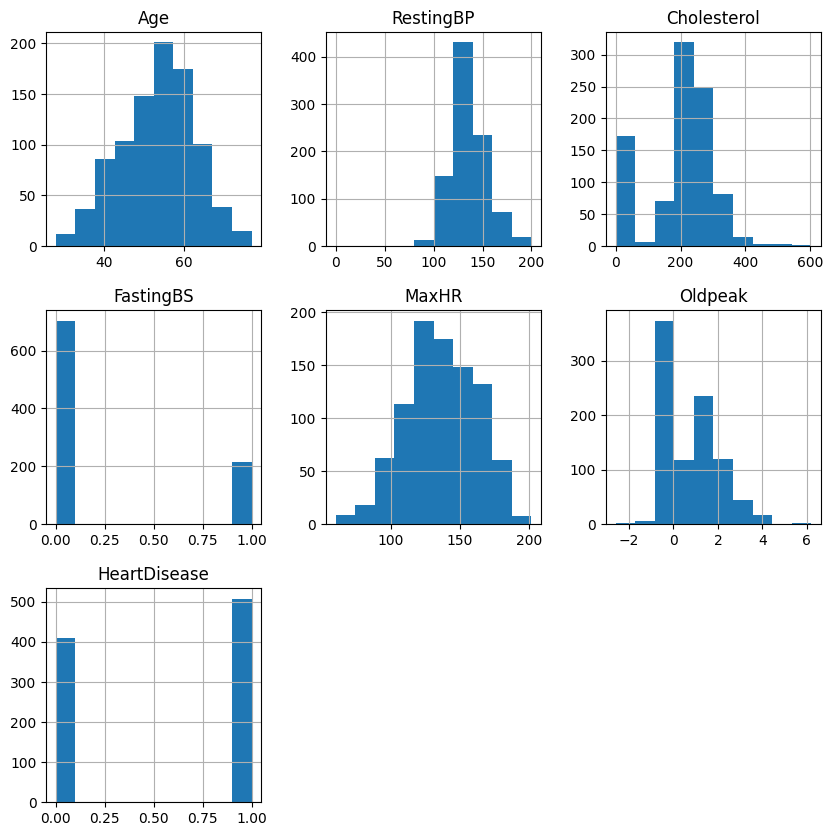

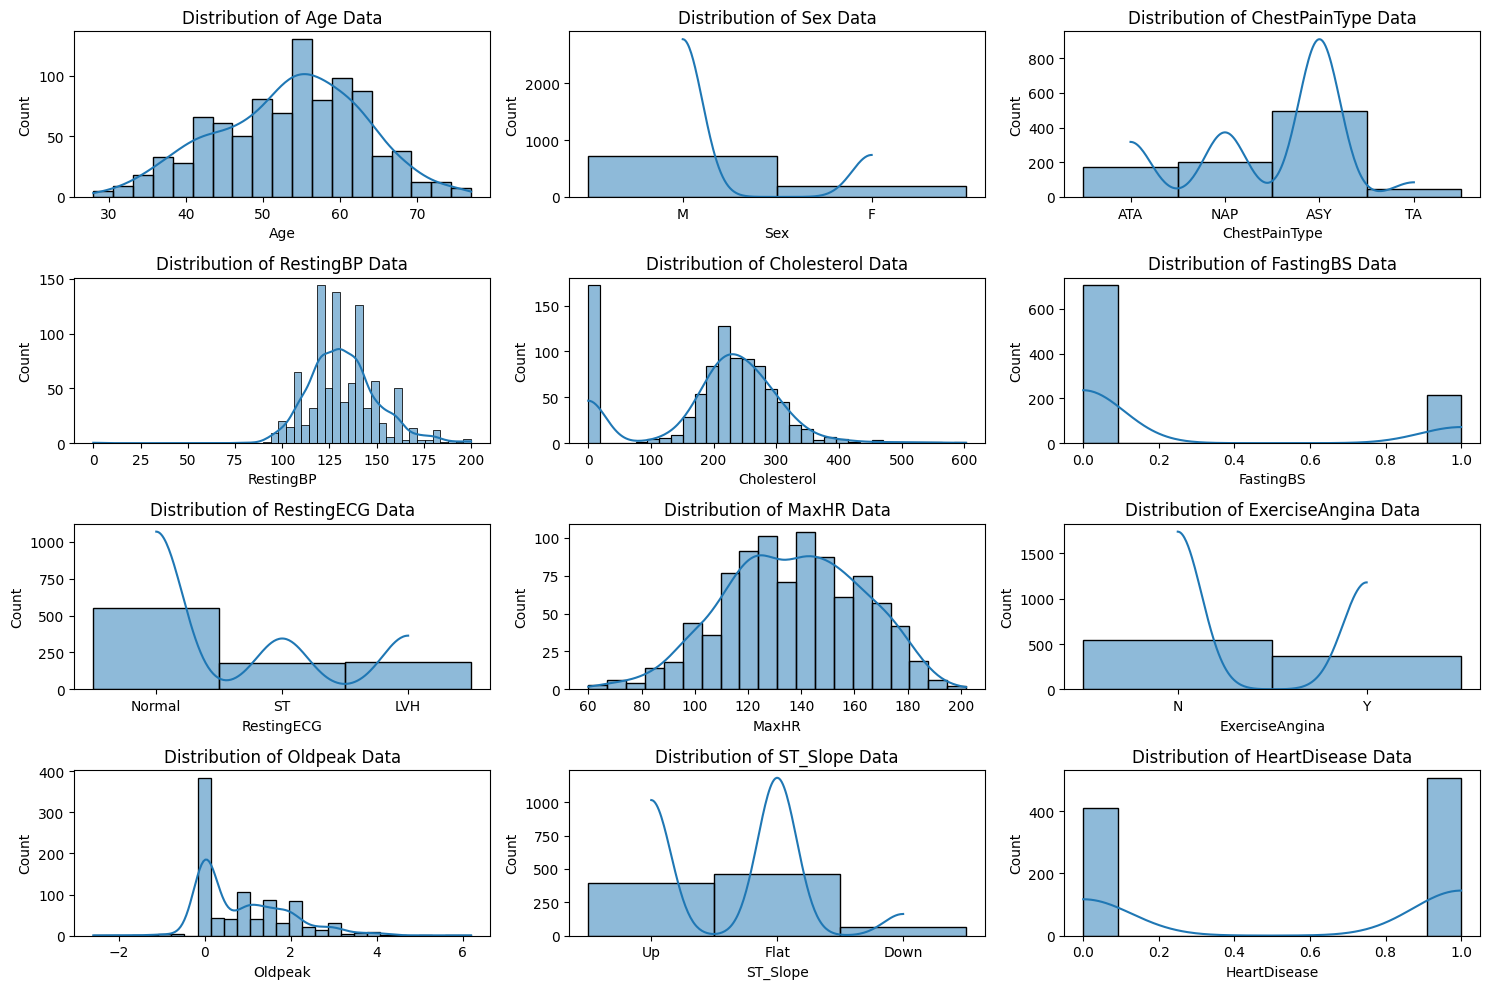

In [9]:
#plot histogram for each numerical attribute as aquick way to get data
df.hist(figsize=(10,10));
#other way to show the distribution of all varaibles
plt.figure(figsize=(15,10))
for i,col in enumerate(df.columns,1):
    plt.subplot(4,3,i)
    plt.title(f"Distribution of {col} Data")
    sns.histplot(df[col],kde=True)
    plt.tight_layout()
    plt.plot()

This dataset contain a mix of numerical and categorical features. The distribuation in age is normal between 40 to 70 years old.It seems that there are outliers in Cholesterol and Resting blood presure, since it is not possible to have zero, therefore it needs to handel by using median. The fasting-bs is a binary varaible with most observations having a value of 0. Only a small proportion has elevated fasting blood sugar and there is a skewed  in some features'distribuations but the skewed will be handled by models .

In [10]:
#check for missing values
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0



There is not any missing values in our dataset.

,count
HeartDisease,
1,508
0,410


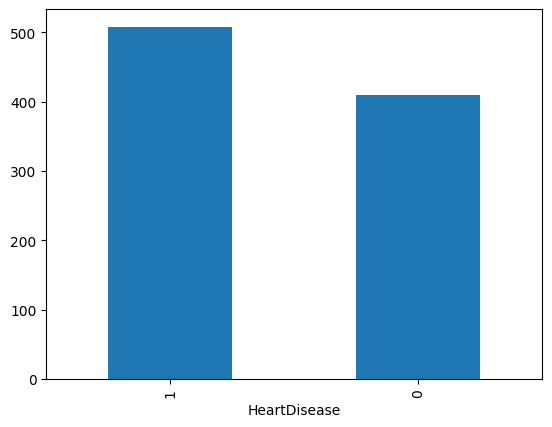

In [11]:
#identifing balanced or imbalanced target
df['HeartDisease'].value_counts().plot(kind='bar')
df['HeartDisease'].value_counts()

The heart fauiler clumn shows relatively balanced distrbution between classes and no need to oversampling or class-weight to adjust, so accuracy can be considered as a reliable metric.

In [12]:
#checking if any row is duplicated
df.duplicated().sum()

np.int64(0)

There are 0 duplicated rows and every patient record is unique.

<Axes: >

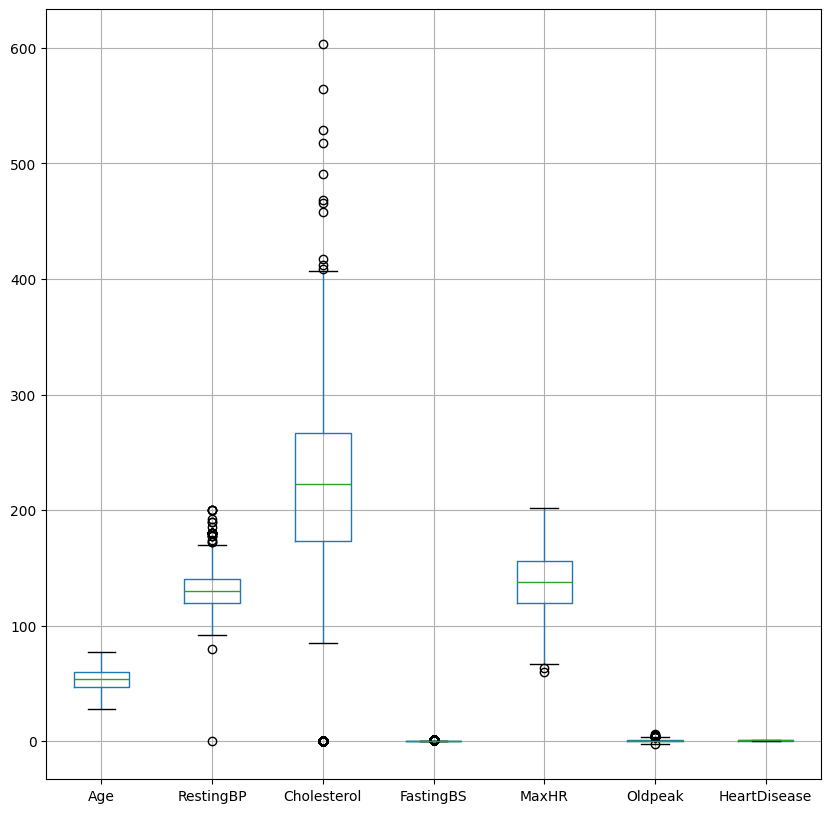

In [13]:
#investigate range of data to find outliers
df.boxplot(figsize=(10,10))

In [14]:
#Encoding
df_encoded = df.copy()
df_encoded['Sex']=df['Sex'].map({'M':0,'F':1})
df_encoded['ExerciseAngina'] = df['ExerciseAngina'].map({'Y':1,'N':0})
df_encoded['ChestPainType'] = df['ChestPainType'].map({'ATA':3,'NAP':2,'ASY':1,'TA':0})
df_encoded['RestingECG'] = df['RestingECG'].map({'Normal':0,'ST':1,'LVH':2})
df_encoded['ST_Slope'] = df['ST_Slope'].map({'Up':2,'Down':0,'Flat':1})

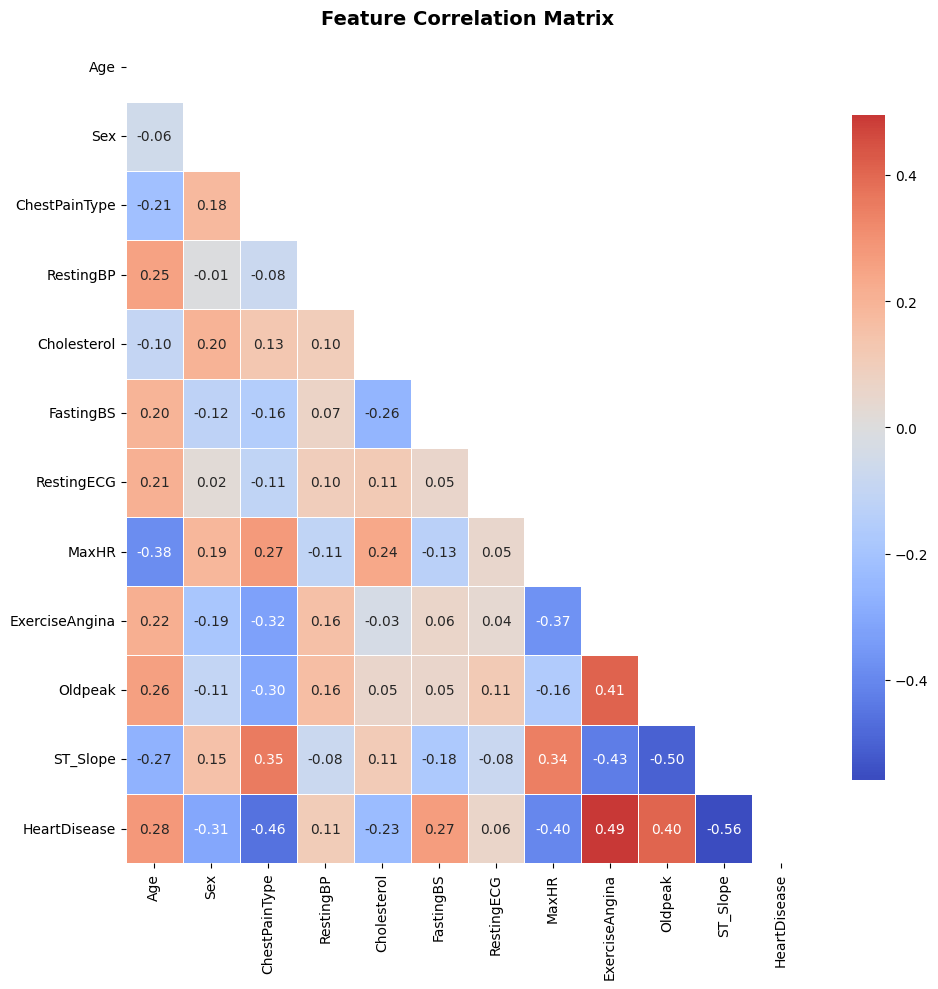

In [15]:
#heatmap
plt.figure(figsize=(10,10))
corr = df_encoded.corr()
#keep only onside of triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
             center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

There is no a significant multicollinearity (not strong coefficient between features)and most of the features correlated to the target;most important features that negatively increase the risk of heart attack are st-slop,maxhr,chestpain and also excersise angia and oldpeak are correlated increasingly to target.

##Data Preprocessing

In [16]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [17]:
#split data to train and test with stratify to keep the same proportion classes in train and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f" X_train.shape:{X_train.shape}\n X_test.shape:{X_test.shape}\n y_train.shape:{y_train.shape}\n y_test.shape:{y_test.shape}")

 X_train.shape:(734, 11)
 X_test.shape:(184, 11)
 y_train.shape:(734,)
 y_test.shape:(184,)


First we want to be sure to put the test set aside  and explore the train set and go to expriment with various transformation.(to avoid data leakage)

In [18]:
numerical_cols =  X_train[['Age','RestingBP','Cholesterol','MaxHR']]
for i in numerical_cols:
  Q1 =X_train[i].quantile(0.25)
  Q3 = X_train[i].quantile(0.75)

  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = X_train[(X_train[i] < lower) | (X_train[i] > upper)]
  outliers_count = len(outliers)
  print(f"The Outliers in {i} are {outliers_count}")

The Outliers in Age are 0
The Outliers in RestingBP are 20
The Outliers in Cholesterol are 140
The Outliers in MaxHR are 2


In [19]:
#treating  null to median
X_train['RestingBP'] = X_train['RestingBP'].replace(0, X_train['RestingBP'].median())
X_test['RestingBP'] = X_test['RestingBP'].replace(0, X_test['RestingBP'].median())

In [20]:
#handling zero values in chlostrol
X_train["Cholesterol"] = X_train["Cholesterol"].replace(0, np.nan)
X_test["Cholesterol"] = X_test["Cholesterol"].replace(0, np.nan)

based on domain knowlege the resting blood presure and Cholesterol is not possible to be zero so it is invalid data and it should be handled. It is used median to replace with zero amounts by using imputer in the pipeline next steps. for outliers robust scaling can help to convert datapoint in range of -1 and 1.

It can be possible to turn zero amounts of chlostrol(implicit) into explicit missing value and the by using imputer we can convert them to median of this column.

In [21]:
numerical_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
categorical_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
binnary_cols = ["Sex", "ExerciseAngina", "FastingBS"]

###-ColumnTransformer

In [22]:
# Numeric pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()) #outlier handler
])
# Categorical pipeline
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Binary pipeline
bin_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="if_binary"))
])

There are features that show imbalanced distributions in binary and categorical variables. However, these distributions reflect real-world data, appropriate preprocessing techniques such as encoding and scaling are used.
Robust scaling is bettre due to the outliers, since it used meadian and IQR for scaling features.Therefore, for numerical values, Robustscaler filled missing values and scaled in outlier-robust way.
Encoder convert data to numbers.
For binary just necessary to fillout the missing data and good to passthrough.

In [23]:
# Combine features for preprocessor of pipeline
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_cols),       # numeric columns
    ("cat", cat_pipeline, categorical_cols),     # categorical columns
    ("bin", bin_pipeline, binnary_cols)          # binary columns
])

##Models & Evaluation

In this section 5 supervised classification algoritjemd comapr and the best model with performance predict the hold out test set.

In order to identify the most suitable model for classification task, multipile ml were selected and compaerd.

In [94]:
#logistic regression
model_lr = Pipeline([("preprocesor",preprocessor),("model",LogisticRegression())])

#defin model hyperparameters
param_grid_lr = {"model__C":[0.01,0.1,1,10],"model__penalty":["l2"]}
grid_lr = GridSearchCV(estimator=model_lr,param_grid=param_grid_lr,cv=5,scoring="accuracy",n_jobs=-1)

#fit model
grid_lr.fit(X_train,y_train)
#
#best params
print("bestparams in LogisticRegression:",grid_lr.best_params_)
print("best CV score:",round(grid_lr.best_score_,2))
#predict model
y_pred_lr = grid_lr.predict(X_test)
y_proba_lr  = grid_lr.predict_proba(X_test)[:, 1]
print("="*50)
#test set evaluation
print("accuracy:",accuracy_score(y_test,y_pred_lr))
print("="*50)
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred_lr))
print("="*50)
print("classfication results:\n",classification_report(y_test,y_pred_lr))

print(f"ROC_AUC_SCORE:{roc_auc_score(y_test, y_proba_lr):.2f}")

bestparams in LogisticRegression: {'model__C': 0.1, 'model__penalty': 'l2'}
best CV score: 0.85
accuracy: 0.8967391304347826
confusion_matrix:
 [[71 11]
 [ 8 94]]
classfication results:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184

ROC_AUC_SCORE:0.93


In [92]:
#decision tree
model_dt = Pipeline([("preprocessor",preprocessor),("model",DecisionTreeClassifier())])

#hyperparametrs
param_grid_dt= {"model__max_depth":[5,10,20],"model__min_samples_split":[2,5,10]}
grid_dt= GridSearchCV(model_dt,param_grid_dt,cv=5,scoring="accuracy",n_jobs=-1)

#train model
grid_dt.fit(X_train,y_train)

#best parameters
print("best params in Decision Tree:",grid_dt.best_params_)
print("best CV score:",round(grid_dt.best_score_,2))

# #predict
y_pred_dt= grid_dt.predict(X_test)
y_proba_dt= grid_dt.predict_proba(X_test)[:, 1]
# #evaluate model
print("accuracy:",accuracy_score(y_test,y_pred_dt))
print("classifiactin:\n",classification_report(y_test,y_pred_dt))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred_dt))
print(f"ROC_AUC_SCORE:{roc_auc_score(y_test,y_proba_dt):.2f}")


best params in Decision Tree: {'model__max_depth': 5, 'model__min_samples_split': 2}
best CV score: 0.82
accuracy: 0.782608695652174
classifiactin:
               precision    recall  f1-score   support

           0       0.76      0.76      0.76        82
           1       0.80      0.80      0.80       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184

confusion matrix:
 [[62 20]
 [20 82]]
ROC_AUC_SCORE:0.84


In [104]:
#RandomForest
model_rf=Pipeline([("preprocessor",preprocessor),("model",RandomForestClassifier())])
param_grid_rf={"model__n_estimators":[50,100,200],"model__max_depth":[5,10]}
grid_rf=GridSearchCV(model_rf,param_grid_rf,cv=5,scoring="accuracy",n_jobs=-1)
grid_rf.fit(X_train,y_train)
print("best params in Random Forest:",grid_rf.best_params_)
print("best CV score:",round(grid_rf.best_score_,2))
y_pred_rf=grid_rf.predict(X_test)
y_proba_rf=grid_rf.predict_proba(X_test)[:,1]
print("accuracy:",accuracy_score(y_test,y_pred_rf))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred_rf))
print("classifiactin:\n",classification_report(y_test,y_pred_rf))
print(f"ROC_AUC_SCORE:{roc_auc_score(y_test,y_proba_rf):.2f}")

best params in Random Forest: {'model__max_depth': 10, 'model__n_estimators': 50}
best CV score: 0.86
accuracy: 0.8641304347826086
confusion matrix:
 [[71 11]
 [14 88]]
classifiactin:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85        82
           1       0.89      0.86      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184

ROC_AUC_SCORE:0.92


In [105]:
#XGBoost
#train model
model_xgb=Pipeline([("preprocessor",preprocessor),("model",XGBClassifier())])
parm_grid_xgb = {"model__n_estimators":[10,100,200],"model__max_depth":[3,5,7],"model__gamma":[0,1,2]}
grid_xgb=GridSearchCV(model_xgb,parm_grid_xgb,cv=5,scoring="accuracy",n_jobs=-1)
grid_xgb.fit(X_train,y_train)
#best patams
print("best params of XGBoost:",grid_xgb.best_params_)
print("best CV score:",round(grid_xgb.best_score_,2))
# #predict
y_pred_xgb=grid_xgb.predict(X_test)
y_proba_xgb=grid_xgb.predict_proba(X_test)[:,1]
print("accuracy:",accuracy_score(y_test,y_pred_xgb))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred_xgb))
print("classifiactin score:\n:",classification_report(y_test,y_pred_xgb))
print(f"ROC_AUC_SCORE:{roc_auc_score(y_test,y_proba_xgb):.2f}")

best params of XGBoost: {'model__gamma': 1, 'model__max_depth': 3, 'model__n_estimators': 10}
best CV score: 0.86
accuracy: 0.8695652173913043
confusion matrix:
 [[68 14]
 [10 92]]
classifiactin score:
:               precision    recall  f1-score   support

           0       0.87      0.83      0.85        82
           1       0.87      0.90      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC_AUC_SCORE:0.93


In [106]:
#Gradient Boosting
model_gb=Pipeline([("preprocessor",preprocessor),("model",GradientBoostingClassifier())])
param_grid_gb={"model__n_estimators":[50,100,200],"model__learning_rate":[0.01,0.1,1]}
grid_gb = GridSearchCV(model_gb,param_grid_gb,cv=5,scoring="accuracy",n_jobs=-1)
grid_gb.fit(X_train,y_train)
print("best params in GradientBoosting:",grid_gb.best_params_)
print("best CV score:",round(grid_gb.best_score_,2))
y_pred_gb=grid_gb.predict(X_test)
y_proba_gb=grid_gb.predict_proba(X_test)[:,1]
print("accuracy:",accuracy_score(y_test,y_pred_gb))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred_gb))
print("classifiactin score:\n:",classification_report(y_test,y_pred_gb))
print(f"ROC_AUC_SCORE:{roc_auc_score(y_test,y_proba_gb):.2f}")

best params in GradientBoosting: {'model__learning_rate': 0.01, 'model__n_estimators': 200}
best CV score: 0.85
accuracy: 0.8695652173913043
confusion matrix:
 [[67 15]
 [ 9 93]]
classifiactin score:
:               precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184

ROC_AUC_SCORE:0.92


In [112]:
#KNN
model_knn = Pipeline([("preprocessor",preprocessor),("model",KNeighborsClassifier())])
param_grid_knn = {"model__n_neighbors":[3,5,7],"model__weights":["uniform","distance"]}

grid_knn = GridSearchCV(model_knn,param_grid_knn,cv=5,scoring="accuracy",n_jobs=-1)
grid_knn.fit(X_train,y_train)
print("best params in KNN:",grid_knn.best_params_)
print("best CV score:",round(grid_knn.best_score_,2))
print("best_param:",grid_knn.best_params_)
print("best CV score:",grid_knn.best_score_)
y_pred_knn=grid_knn.predict(X_test)
y_proba_knn = grid_knn.predict_proba(X_test)[:,1]
print("="*65)
print("accuracy:",accuracy_score(y_test,y_pred_knn))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred_knn))
print("classifiactin score:\n:",classification_report(y_test,y_pred_knn))
print(f"ROC_AUC_SCORE:{roc_auc_score(y_test,y_proba_knn):.2f}")

best params in KNN: {'model__n_neighbors': 7, 'model__weights': 'uniform'}
best CV score: 0.85
best_param: {'model__n_neighbors': 7, 'model__weights': 'uniform'}
best CV score: 0.8487093467523996
accuracy: 0.8641304347826086
confusion matrix:
 [[69 13]
 [12 90]]
classifiactin score:
:               precision    recall  f1-score   support

           0       0.85      0.84      0.85        82
           1       0.87      0.88      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

ROC_AUC_SCORE:0.93


In [147]:
#SVM
model_svm =Pipeline([("preprocessor",preprocessor),("model",SVC(probability=True))])
param_grid_svm = {"model__C":[0.1,1,10],"model__kernel":["linear","rbf"]}
grid_svm = GridSearchCV(model_svm,param_grid_svm,cv=5,scoring='accuracy')
#fit model
grid_svm.fit(X_train,y_train)
print("best params in SVM:",grid_svm.best_params_)
print("best CV score:",round(grid_svm.best_score_,2))
# #predict
y_pred_svm=grid_svm.predict(X_test)
y_proba_svm = grid_svm.predict_proba(X_test)[:,1]
print("="*65)
print("accuracy:",accuracy_score(y_test,y_pred_svm))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred_svm))
print("classifiactin score:\n:",classification_report(y_test,y_pred_svm))
print(f"ROC_AUC_SCORE:{roc_auc_score(y_test,y_proba_svm):.2f}")


best params in SVM: {'model__C': 1, 'model__kernel': 'rbf'}
best CV score: 0.86
accuracy: 0.8586956521739131
confusion matrix:
 [[68 14]
 [12 90]]
classifiactin score:
:               precision    recall  f1-score   support

           0       0.85      0.83      0.84        82
           1       0.87      0.88      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

ROC_AUC_SCORE:0.94


In [84]:
#voting ensemble(it is alredy built from tuned model no need to ude gridsearch to tune)
model_voting = VotingClassifier(estimators=[
    ("lr",grid_lr.best_estimator_),
     ("dt",grid_dt.best_estimator_),
 ("gb",grid_gb.best_estimator_),
  ("SVM",grid_svm.best_estimator_),
  ("KNN",grid_knn.best_estimator_),
   ("rf",grid_rf.best_estimator_),
    ("xgb",grid_xgb.best_estimator_)],
                                voting='soft')#support probability)
voting_scores= cross_val_score(model_voting,X_train,y_train,cv=5,scoring="accuracy")
print("voting scores:",round(voting_scores.mean(),2))

voting scores: 0.86


In [82]:
#model prediction on hold out test set
model_voting.fit(X_train,y_train)
y_pred=model_voting.predict(X_test)
y_pred_proba=model_voting.predict_proba(X_test)[:,1]
print("accuracy:",f"{accuracy_score(y_test,y_pred):.2f}")
print("consion matrix:\n",confusion_matrix(y_test,y_pred))
print("classfication:\n",classification_report(y_test,y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.2f}")

accuracy: 0.88
consion matrix:
 [[70 12]
 [11 91]]
classfication:
               precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184

AUC: 0.94


In [140]:
#select the best model
results=[
{'Model':'Logistic Regression','CV AUC':0.85,'Test Accuracy':0.897,'Test AUC': 0.93, 'Recall':0.92 , 'Precision':0.90 ,'F1': 0.91,'TN':71,'FP':11, 'FN': 8,'TP':94},
{'Model': 'Decision Tree','CV AUC': 0.82, 'Test Accuracy': 0.783,'Test AUC': 0.84, 'Recall': 0.80, 'Precision': 0.80, 'F1': 0.80,'TN': 62, 'FP': 20, 'FN': 20, 'TP': 82},
{'Model': 'Random Forest', 'CV AUC': 0.86, 'Test Accuracy': 0.864, 'Test AUC': 0.92, 'Recall': 0.86, 'Precision': 0.89, 'F1': 0.88,'TN': 71, 'FP': 11, 'FN': 14, 'TP': 88},
{'Model': 'XGBoost','CV AUC': 0.86, 'Test Accuracy': 0.870,'Test AUC': 0.93, 'Recall': 0.90, 'Precision': 0.87, 'F1': 0.88,'TN': 68, 'FP': 14, 'FN': 10, 'TP': 92},
{'Model': 'Gradient Boosting','CV AUC': 0.85, 'Test Accuracy': 0.870,  'Test AUC': 0.92, 'Recall': 0.91, 'Precision': 0.86, 'F1': 0.89, 'TN': 67, 'FP': 15, 'FN': 9,  'TP': 93},
{'Model': 'KNN','CV AUC': 0.85, 'Test Accuracy': 0.864, 'Test AUC': 0.93, 'Recall': 0.88, 'Precision': 0.87, 'F1': 0.88, 'TN': 69, 'FP': 13, 'FN': 12, 'TP': 90},
{'Model': 'SVM','CV AUC': 0.86, 'Test Accuracy': 0.859,  'Test AUC': 0.94, 'Recall': 0.88, 'Precision': 0.87, 'F1': 0.87,  'TN': 68, 'FP': 14, 'FN': 12, 'TP': 90},
{'Model': 'Voting Ensemble','CV AUC': 0.86, 'Test Accuracy': 0.880,   'Test AUC': 0.94, 'Recall': 0.89, 'Precision': 0.88, 'F1': 0.89,  'TN': 70, 'FP': 12, 'FN': 11, 'TP': 91}]

df_results=(pd.DataFrame(results).sort_values("Recall",ascending=False).reset_index(drop=True))#sensitive to recall
print(df_results.to_string(index=False))

              Model  CV AUC  Test Accuracy  Test AUC  Recall  Precision   F1  TN  FP  FN  TP
Logistic Regression    0.85          0.897      0.93    0.92       0.90 0.91  71  11   8  94
  Gradient Boosting    0.85          0.870      0.92    0.91       0.86 0.89  67  15   9  93
            XGBoost    0.86          0.870      0.93    0.90       0.87 0.88  68  14  10  92
    Voting Ensemble    0.86          0.880      0.94    0.89       0.88 0.89  70  12  11  91
                KNN    0.85          0.864      0.93    0.88       0.87 0.88  69  13  12  90
                SVM    0.86          0.859      0.94    0.88       0.87 0.87  68  14  12  90
      Random Forest    0.86          0.864      0.92    0.86       0.89 0.88  71  11  14  88
      Decision Tree    0.82          0.783      0.84    0.80       0.80 0.80  62  20  20  82


### Final Model Selection and details
Although cross val score on traing test shows SVM, Voting Ensemble,XGBoost and random Forest are higher, it is not garanteed to have best performance on unseen data to predict real sickness.
For a heart disease prediction the informative metric is Recall since False Negative(the model says no disease but paitent ha diseases) is more dangeraous and impact on management cost.
In this case,LR caught 94 paitents and missed 8. since minimizing false negative is the primary objective this model selected as a final recommended model.the model learned with c1=0.1 and regularization l2 with scalling inside the pipeine, with no sign of overfitting(cv score and hold-out test score) and has the highest accuracy at
89.7%.
-Strengths and limitations: the small dataset and not covering some features like addiction,BMI,genetic to have an accurate prediction. the other weakness is underperformncing of Desision Tree which scored low (78%) on traing test that indicates it is better to have more than one trees to classify.
However avoiding dataleakage by using pipeline is strong point.


